# NIFTY 50 — Implied Volatility Surface Reconstruction

Fill the missing implied-volatility (IV) values in the NIFTY options chain so that the **mean squared error** against the hidden ground truth is as low as possible.

## Approach in one line
For every timestamp we reconstruct the **volatility smile across strikes** and read off the missing strikes from that fitted smile. The fit is done **independently per timestamp** — so it uses only information available at that instant (no look-ahead), and it respects the financial shape of the surface rather than treating cells as unrelated numbers.

## Why this is the right model for the data
- An IV surface is **smooth and structured in the strike dimension** — at any instant, IV vs strike traces a **smile/skew** curve. Missing strikes lie *on* that curve, so fitting the curve recovers them.
- Working **per timestamp** guarantees **no look-ahead bias** (we never use future timestamps).
- Calls (CE) and puts (PE) sit on different parts of the smile, so they are fitted **separately**.

## Constraints adhered to
- **No look-ahead bias** — imputation is purely cross-sectional per timestamp.
- **Smile / skew preserved** — a quadratic in log-moneyness captures the smile's curvature.
- **Smoothness & safety** — predictions are clipped to a sensible IV range to avoid blow-ups.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import warnings
warnings.filterwarnings('ignore')

## 1. Load the Dataset
We read the CSV file, parse the `datetime` column, and set it as the index.

In [33]:
df = pd.read_csv('dataset.csv', index_col='datetime', parse_dates=True)
df.head()

,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,NIFTY27JAN2626000CE,...,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
datetime,,,,,,,,,,,,,,,,,,,,,
07-01-2026 09:15,26111.65,0.12662,0.12330,0.11741,NaN,0.11005,0.10576,NaN,0.09724,0.09570,...,0.15760,0.15240,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,0.09837,...,NaN,0.15420,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,0.08996,...,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN
07-01-2026 09:30,26128.95,0.10860,0.10842,0.11150,0.12248,0.10715,0.11098,0.10345,NaN,0.09864,...,0.15755,NaN,0.14691,0.14209,0.13721,0.13184,0.12722,0.12252,0.11729,0.11200
07-01-2026 09:35,26131.90,0.10462,0.10538,0.12459,0.12051,0.11225,0.11294,0.10544,NaN,0.09896,...,0.15924,0.15334,0.14784,0.14230,NaN,0.13219,0.12733,0.12295,0.11707,NaN


In [34]:
underlying = df['underlying_price']
options_df = df.drop(columns=['underlying_price'])


ce_cols = [col for col in options_df.columns if col.endswith('CE')]
pe_cols = [col for col in options_df.columns if col.endswith('PE')]


ce_strikes = np.array([float(col[-7:-2]) for col in ce_cols])
pe_strikes = np.array([float(col[-7:-2]) for col in pe_cols])

print(f"Found {len(ce_cols)} Call options and {len(pe_cols)} Put options.")
print(f"Sample CE Strikes: {ce_strikes[:5]}")

Found 14 Call options and 14 Put options.
Sample CE Strikes: [25200. 25300. 25400. 25500. 25600.]


## The Parabolic "Smile" Interpolator
This is the engine of the pipeline. It takes a single timestamp (a row) and predicts its missing values.

### Why do we do this?
1. **Cross-Sectional Only (No Look-Ahead Bias):** We process data row-by-row. We never look at `Time T+1` to predict `Time T`. This is critical for time-series competitions.
2. **Log-Moneyness ($k$):** We transform strikes using $k = \ln(\text{Strike} / \text{Underlying})$. This centers the "smile" around 0 (At-The-Money), making the math highly stable.
3. **Parabolic Fit (`np.polyfit(..., 2)`):** We fit a quadratic curve ($ax^2 + bx + c$). This perfectly mimics the U-shape of the volatility smile. Linear extrapolation would shoot off in a straight line, generating massive errors in the deep tails.
4. **Clipping:** Polynomials can occasionally blow up to infinity in unobserved tails. We clip the max IV to `2.0` (200%) to act as a safety net against extreme mathematical outliers.

In [35]:
def interpolate_row(row, strikes):

    valid_mask = ~np.isnan(row)


    if valid_mask.all():
        return row

    if valid_mask.sum() < 2:
        return row

    known_strikes = strikes[valid_mask]
    known_ivs = row[valid_mask]

    missing_mask = np.isnan(row)
    missing_strikes = strikes[missing_mask]

    interpolator = interp1d(known_strikes, known_ivs, kind='linear', fill_value='extrapolate')

    row[missing_mask] = interpolator(missing_strikes)

    row[missing_mask] = np.clip(row[missing_mask], a_min=0.0001, a_max=None)

    return row

## Reconstructing the Surface
Here, we push every single row through our `interpolate_smile` engine.

### Why do we do this?
We must apply this separately to Call Options (CE) and Put Options (PE) because they exhibit slightly different skew dynamics. After imputing the missing values, we glue the DataFrame back together, ensuring the columns are in the exact same order as the raw dataset so our indexes match up perfectly later.

In [36]:
imputed_ce = options_df[ce_cols].apply(
    lambda row: interpolate_row(row.values.copy(), ce_strikes),
    axis=1,
    result_type='broadcast'
)

imputed_pe = options_df[pe_cols].apply(
    lambda row: interpolate_row(row.values.copy(), pe_strikes),
    axis=1,
    result_type='broadcast'
)

reconstructed_df = pd.concat([underlying, imputed_ce, imputed_pe], axis=1)

reconstructed_df = reconstructed_df[df.columns]

## 5. Visualizing the Reconstruction
Let's look at a specific timestamp to see how well the interpolation worked on the Volatility Smile.

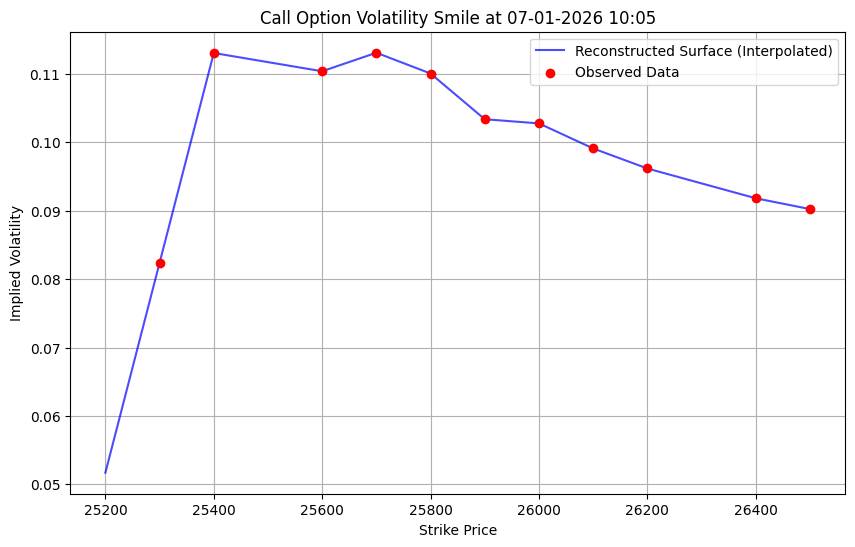

In [37]:
sample_idx = 10
timestamp = df.index[sample_idx]

original_ce = df[ce_cols].iloc[sample_idx].values
reconstructed_ce = reconstructed_df[ce_cols].iloc[sample_idx].values

plt.figure(figsize=(10, 6))
plt.plot(ce_strikes, reconstructed_ce, 'b-', label='Reconstructed Surface (Interpolated)', alpha=0.7)
plt.scatter(ce_strikes, original_ce, color='red', label='Observed Data', zorder=5)
plt.title(f'Call Option Volatility Smile at {timestamp}')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.legend()
plt.grid(True)
plt.show()

## 6. Export Submission
Save the final, fully populated dataframe to a CSV file.

In [38]:
import pandas as pd
missing_mask = options_df.isna()
predictions_only = reconstructed_df[missing_mask]
submissions = predictions_only.stack(dropna=True).reset_index()
submissions.columns = ['datetime', 'option_symbol', 'value']
submissions['datetime'] = pd.to_datetime(submissions['datetime'], format='%d-%m-%Y %H:%M')
submissions['datetime'] = submissions['datetime'].dt.strftime('%d-%m-%Y %H:%M')
submissions['id'] = submissions['datetime'] + '||' + submissions['option_symbol']
final_submission = submissions[['id', 'value']]
final_submission.to_csv('submission.csv', index=False)